<a href="https://colab.research.google.com/github/haru452/anime_super-resolution/blob/main/Lauer2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import glob
import cv2
import numpy as np

# Adjust the path to your Google Drive where the images are located
# For example, if your images are directly in 'My Drive', use '/content/drive/My Drive/bs*.png'
# If they are in a subfolder, e.g., 'My Drive/Images', use '/content/drive/My Drive/Images/bs*.png'
paths = sorted(glob.glob('/content/drive/My Drive/Graduate/Craters/bs*.png'))  # bs1.png ~ bs4.png
images = []
i = 0
for p in paths:
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE).astype(np.float32)
    new_size = (img.shape[1] // 2, img.shape[0] // 2)
    img2 = cv2.resize(img, new_size, interpolation=cv2.INTER_CUBIC)
    images.append(img2)
    i+=1

# サイズが全部同じか確認 (Check if all sizes are the same)
if images:
    for i, img in enumerate(images):
        print(i, img.shape)
else:
    print("No images found. Please check the path and filename pattern in your Google Drive.")

0 (128, 128)
1 (128, 128)
2 (128, 128)
3 (128, 128)


In [ ]:
def check_rotation(img0, img1):
    orb = cv2.ORB_create(500)
    kp1, des1 = orb.detectAndCompute(img0.astype(np.uint8), None)
    kp2, des2 = orb.detectAndCompute(img1.astype(np.uint8), None)
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = sorted(bf.match(des1, des2), key=lambda m: m.distance)[:50]
    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])
    M, _ = cv2.estimateAffinePartial2D(pts1, pts2)
    angle = np.degrees(np.arctan2(M[1, 0], M[0, 0]))
    scale = np.sqrt(M[0, 0]**2 + M[1, 0]**2)
    print(f"回転角: {angle:.3f}°, スケール: {scale:.4f}")
    return M

for i in range(1, len(images)):
    check_rotation(images[0], images[i])

回転角: -3.951°, スケール: 1.0140
回転角: -0.259°, スケール: 1.0228
回転角: -5.181°, スケール: 1.0357


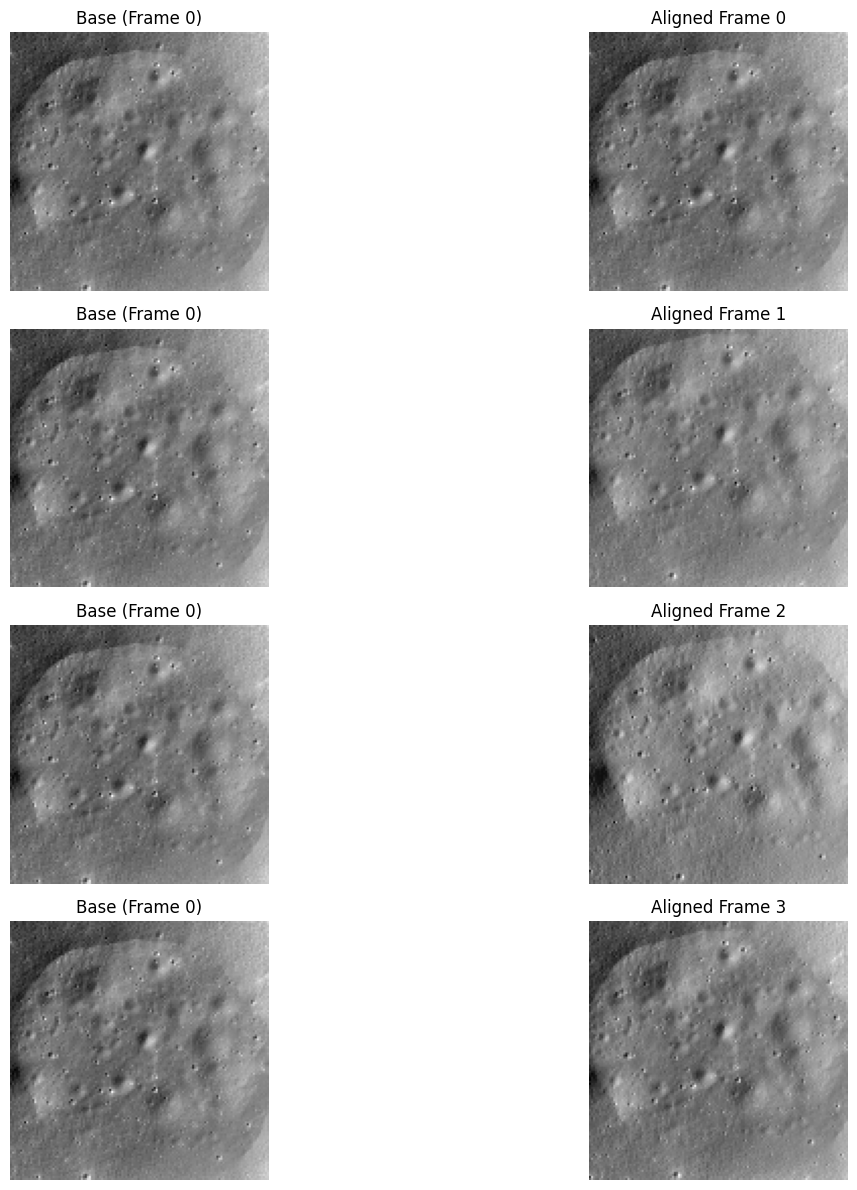


--- 基準フレームとの差分 (明るさ正規化済: 位置のズレのみを可視化) ---


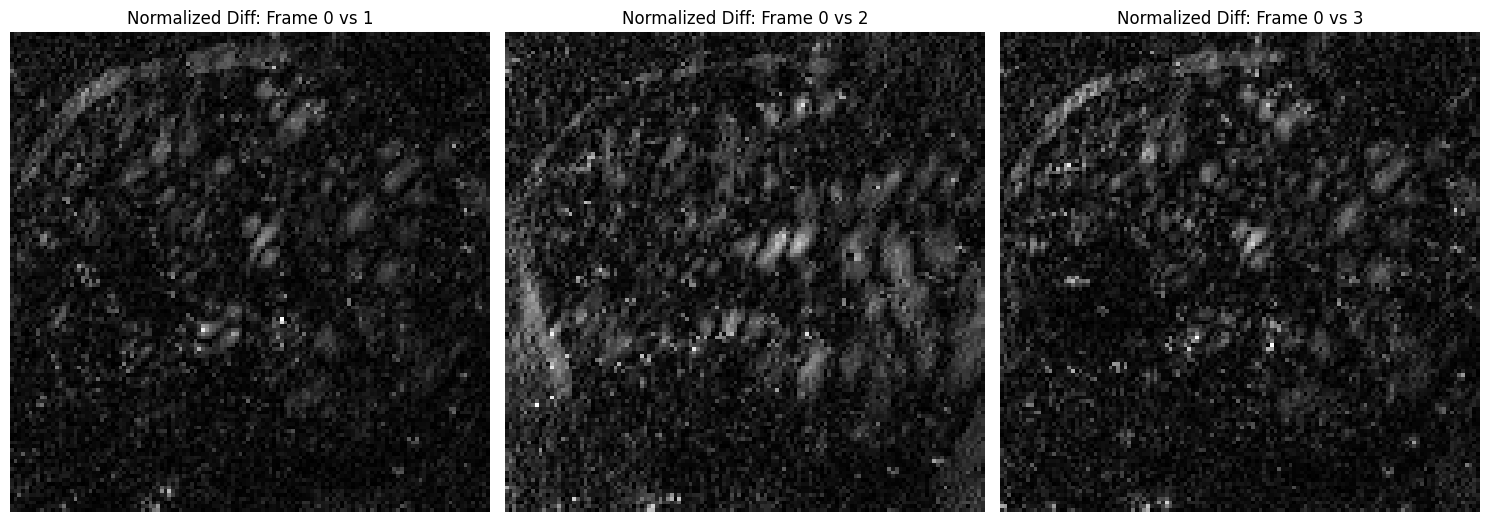

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def visualize_alignment_results_with_norm(base_image, aligned_images):
    """
    回転補正後の画像を基準画像(Frame 0)と比較し、
    さらに輝度（明るさ）を正規化した上で差分を表示する関数
    """
    num_images = len(aligned_images)
    base_img_f = base_image.astype(np.float32)
    base_mean = np.mean(base_img_f)

    # 1. 基準画像と補正後画像の並べて比較（目視チェック用）
    plt.figure(figsize=(15, 3 * num_images))
    for i, img in enumerate(aligned_images):
        plt.subplot(num_images, 2, 2 * i + 1)
        plt.imshow(base_image, cmap='gray')
        plt.title("Base (Frame 0)")
        plt.axis('off')

        plt.subplot(num_images, 2, 2 * i + 2)
        plt.imshow(img, cmap='gray')
        plt.title(f"Aligned Frame {i}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # 2. 輝度正規化を行った上での差分表示
    print("\n--- 基準フレームとの差分 (明るさ正規化済: 位置のズレのみを可視化) ---")
    plt.figure(figsize=(15, 3 * num_images))

    for i, img in enumerate(aligned_images):
        if i == 0:
            continue  # Frame 0 同士の差分はスキップ

        img_f = img.astype(np.float32)
        img_mean = np.mean(img_f)

        # 💡 ここで明るさの平均値を Frame 0 に合わせて正規化します
        # ゼロ除算を防ぐため、微小値 (1e-8) を分母に足しています
        img_normalized = img_f * (base_mean / (img_mean + 1e-8))

        # クリップ処理をしてから8bitに変換し、絶対値差分を計算
        img_normalized_8u = np.clip(img_normalized, 0, 255).astype(np.uint8)
        diff = cv2.absdiff(base_image.astype(np.uint8), img_normalized_8u)

        plt.subplot(1, num_images - 1, i)
        plt.imshow(diff, cmap='gray')
        plt.title(f"Normalized Diff: Frame 0 vs {i}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# 実行コード（アライメント済みの images リストがある前提）
if 'images' in locals() and len(images) > 0:
    visualize_alignment_results_with_norm(images[0], images)
else:
    print("エラー: images リストが見つからないか、空です。先にアライメントのセルを実行してください。")

In [ ]:
def align_rotation(base, img):
    orb = cv2.ORB_create(1000)
    kp1, des1 = orb.detectAndCompute(base.astype(np.uint8), None)
    kp2, des2 = orb.detectAndCompute(img.astype(np.uint8), None)
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = sorted(bf.match(des1, des2), key=lambda m: m.distance)[:50]
    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])
    M, _ = cv2.estimateAffinePartial2D(pts2, pts1)  # imgをbaseに合わせる方向
    h, w = base.shape
    aligned = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR)
    return aligned

images = [images[0]] + [align_rotation(images[0], img) for img in images[1:]]

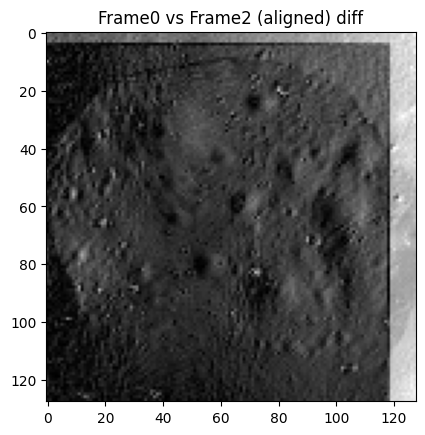

In [ ]:
diff = cv2.absdiff(images[0].astype(np.uint8), images[2].astype(np.uint8))
plt.imshow(diff, cmap='gray'); plt.title("Frame0 vs Frame2 (aligned) diff"); plt.show()

フレーム間のサブピクセルズレを推定中...
Frame 0: dx = +0.0000, dy = +0.0000
Frame 1: dx = -0.0448, dy = +0.1775
Frame 2: dx = +0.1428, dy = +0.3930
Frame 3: dx = -0.5356, dy = +0.1768
超解像処理を実行中...


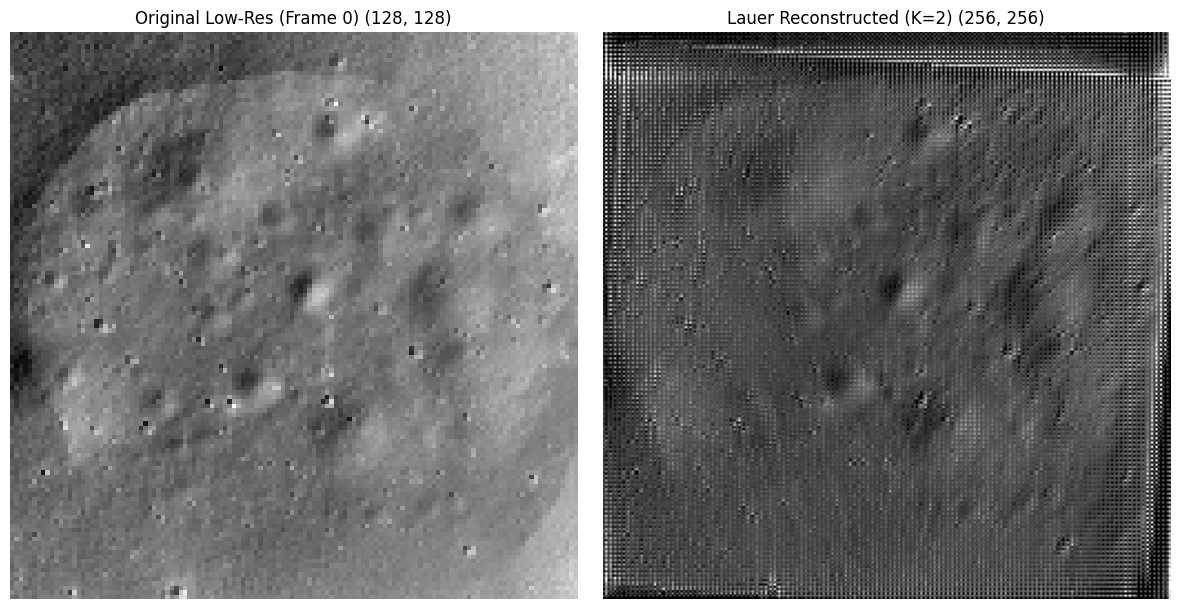

結果を 'video_super_resolution_result.png' に保存しました。


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# ----------------------------------------------------
# 1. 動き推定（1フレーム目を基準としたサブピクセルズレの計算）
# ----------------------------------------------------
def estimate_offsets(frames):
    """
    1枚目のフレームを基準(0, 0)とし、各フレームのサブピクセル単位のズレ(dx, dy)を推定する。
    """
    offsets = []
    base_frame = frames[0].astype(np.float32)

    # 周辺部のノイズを抑え、位相限定相関の精度を上げるためのハニング窓を作成
    """
    ハニング窓とは
    ただ単純にデータを四角く切り取ると（これを矩形窓と呼びます）、切り取った両端のデータが突然途切れるため、不連続な「崖」のような段差が生まれてしまいます。この段差のせいで、本来のデータには存在しない偽の高周波成分（ノイズ）が発生してしまいます。これを漏れ誤差（サイドローブ、リーケージ）と呼びます。

    ハニング窓は、中央のデータをしっかり残しつつ、端に向かって緩やかなカーブ（コサイン波の形状）を描いて綺麗にゼロに落とすことで、この「崖」をなくし、正確な周波数解析を行えるようにします。
    つまり、ノイズを減らすってこと。このLauerのアルゴリズムはノイズがあるとやばいしね
    """
    h, w = base_frame.shape
    win = cv2.createHanningWindow((w, h), cv2.CV_32F)

    for i, frame in enumerate(frames):
        if i == 0:
            offsets.append((0.0, 0.0))
            continue

        # 位相限定相関法 (Phase Correlation) により、サブピクセル精度のズレを検出
        # shift = (dx, dy)
        shift, _ = cv2.phaseCorrelate(base_frame, frame.astype(np.float32), win)
        dx, dy = shift
        """
        卒論方針発表のために作ったスライドをみたら、わかると思う。
        この位相限定相関法が何なのか
        どうやってOpenCVで実装するのか
        """

        offsets.append((dx, dy))

    return offsets

# ----------------------------------------------------
# 2. Lauerのアルゴリズム（過剰決定系・最小二乗法）
# ----------------------------------------------------
def lauer_reconstruct_overdetermined(images, K, offsets):
    N = len(images)

    # 輝度変化を吸収するための正規化処理
    base_mean = np.mean(images[0])
    normalized_images = [img * (base_mean / (np.mean(img) + 1e-8)) for img in images]

    # h, w は低解像度画像のサイズ。H, W は復元したい高解像度画像のサイズ。
    h, w = images[0].shape
    H, W = h * K, w * K

    # S は各低解像度画像をスパース配列（間引き配列）にしてFFTしたものを格納
    S = np.zeros((N, H, W), dtype=complex)
    for n in range(N):
        sparse_img = np.zeros((H, W))
        sparse_img[::K, ::K] = normalized_images[n]  # 1ピクセルおきにデータを配置
        S[n] = np.fft.fft2(sparse_img)

    # 復元後の高解像度フーリエ空間の座標軸を作成
    u = np.fft.fftfreq(W)
    v = np.fft.fftfreq(H)
    U_2d, V_2d = np.meshgrid(u, v)

    # K=2の場合、フーリエ空間は4つの領域に分かれ、それぞれがエイリアスとして重なっている
    U_vals = np.stack([
        U_2d[:H//2, :W//2], U_2d[H//2:, :W//2],
        U_2d[:H//2, W//2:], U_2d[H//2:, W//2:]
    ], axis=-1)

    V_vals = np.stack([
        V_2d[:H//2, :W//2], V_2d[H//2:, :W//2],
        V_2d[:H//2, W//2:], V_2d[H//2:, W//2:]
    ], axis=-1)

    # 観測データ（方程式の右辺 D に相当）の抽出
    D_vec = S[:, :H//2, :W//2]
    D_trans = np.transpose(D_vec, (1, 2, 0))  # 形を (H/2, W/2, N) に変更

    # 係数行列（方程式の左辺の係数 Φ に相当）の作成
    Phi = np.zeros((H//2, W//2, N, 4), dtype=complex)
    for n in range(N):
        dx, dy = offsets[n]
        # 【修正箇所】低解像度のズレ(dx, dy)を高解像度空間の周波数シフトに適用するため、* K を追加
        phase = np.exp(-2j * np.pi * (U_vals * dx * K + V_vals * dy * K))
        Phi[:, :, n, :] = phase / (K**2)

    # 最小二乗法による疑似逆行列の計算
    Phi_pinv = np.linalg.pinv(Phi)  # 形は (H/2, W/2, 4, N)

    # 疑似逆行列と観測データを掛け合わせて、真のフーリエ成分 F を導出
    F_vals = np.einsum('...ij,...j->...i', Phi_pinv, D_trans)  # 形は (H/2, W/2, 4)

    # 分離された4つのエイリアス成分を高解像度フーリエ空間の正しい位置に配置
    F_recon = np.zeros((H, W), dtype=complex)
    F_recon[:H//2, :W//2] = F_vals[..., 0]  # 左上
    F_recon[H//2:, :W//2] = F_vals[..., 1]  # 左下
    F_recon[:H//2, W//2:] = F_vals[..., 2]  # 右上
    F_recon[H//2:, W//2:] = F_vals[..., 3]  # 右下

    # 逆フーリエ変換を行って現実の画像空間に戻す
    reconstructed_img = np.fft.ifft2(F_recon)
    return np.real(reconstructed_img)


# ----------------------------------------------------
# 3. メイン処理（動画読み込みと実行）
# ----------------------------------------------------




# ① 動き（ズレ量）の自動推定
print("フレーム間のサブピクセルズレを推定中...")
estimated_offsets = estimate_offsets(images) # low_res_frames を images に変更

for i, (dx, dy) in enumerate(estimated_offsets):
    print(f"Frame {i}: dx = {dx:+.4f}, dy = {dy:+.4f}")

# ② Lauerのアルゴリズムを実行 (倍率 K=2)
K = 2
print("超解像処理を実行中...")
result = lauer_reconstruct_overdetermined(images, K=K, offsets=estimated_offsets) # low_res_frames を images に変更

# 0-255の範囲に数値をクリップ（はみ出し対策）
result_clipped = np.clip(result, 0, 255).astype(np.uint8)

# ③ 結果の表示と保存
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title(f"Original Low-Res (Frame 0) {images[0].shape}") # low_res_frames を images に変更
plt.imshow(images[0], cmap='gray') # low_res_frames を images に変更
plt.axis('off')
cv2.imwrite("video_orign.png", images[0]) # low_res_frames を images に変更

plt.subplot(1, 2, 2)
plt.title(f"Lauer Reconstructed (K={K}) {result_clipped.shape}")
plt.imshow(result_clipped, cmap='gray')

plt.axis('off')

plt.tight_layout()
plt.show()

cv2.imwrite("video_super_resolution_result.png", result_clipped)
print("結果を 'video_super_resolution_result.png' に保存しました。")